# Photo-z estimation with Flex z Boost

In [72]:
### Imports
import numpy as np
import h5py

import rail.interactive as ri
import tables_io
from rail.utils.path_utils import find_rail_file

# Model parameters

In [2]:
data_file_path = '/Users/leo/Projects/LBG_cosmology/simulated_catalogs/integrated_catalog_23apr26_noised_19Jun26.pq'

training_fraction = 0.8
reference_band = 'LSST_u'

flexZBoost_parameters = dict(
    zmin              = 0.0,
    zmax              = 3.0,
    nzbins            = 301,
    trainfrac         = 0.75,
    bumpmin           = 0.02,
    bumpmax           = 0.35,
    nbump             = 20,
    sharpmin          = 0.7,
    sharpmax          = 2.1,
    nsharp            = 15,
    max_basis         = 35,
    basis_system      = "cosine",
    regression_params = {"max_depth": 8, "objective": "reg:squarederror"},
)

seed = 42

In [3]:
m5_limiting_depths = {'LSST_u'    : 27.74,
                      'LSST_g'    : 28.69,
                      'LSST_r'    : 28.88,
                      'LSST_i'    : 28.96,
                      'LSST_z'    : 28.26,
                      'LSST_y'    : 26.63,
                      'Roman_F062': 27.7,
                      'Roman_F087': 27.7,
                      'Roman_F106': 27.6,
                      'Roman_F129': 27.5,
                      'Roman_F158': 27.0,
                      'Roman_F184': 25.9,
                      'Roman_F213': 28.3,
                      'HSC_MB_00' : 26.41,
                      'HSC_MB_01' : 26.51,
                      'HSC_MB_02' : 26.45,
                      'HSC_MB_03' : 26.69,
                      'HSC_MB_04' : 26.93,
                      'HSC_MB_05' : 26.62,
                      'HSC_MB_06' : 26.26,
                      'HSC_MB_07' : 26.02,
                      'HSC_MB_08' : 26.07,
                      'HSC_MB_09' : 26.00,
                      'HSC_MB_10' : 26.06,
                      'HSC_MB_11' : 25.52,
                      'HSC_MB_12' : 25.58,
                      'HSC_MB_13' : 25.43,
                      'HSC_MB_14' : 25.15,
                      'HSC_MB_15' : 24.79}

# Load data

In [4]:
data_cut = int(1e5)

In [5]:
data_file = find_rail_file(data_file_path)
data = tables_io.read(data_file)

data = data[:data_cut]

training_indices = np.zeros(len(data), dtype = bool)
training_indices[np.random.choice(len(data), size = int(training_fraction * len(data)),
                 replace = False)] = True

bands = [key for key in data.keys() if (not key.endswith('_err')) & (key != 'Roman_F146')]
error_bands = [key for key in data.keys() if key.endswith('_err')]

validation_data = data[~training_indices]
training_data   = data[training_indices]

column_list None


In [6]:
redshift_filepath = '/Users/leo/Projects/LBG_cosmology/surveys/pop-cosmos/mock_catalog/mock_catalog_Ch1_26.h5'
redshifts = h5py.File(redshift_filepath)['sfh_parameters'][:, -1]

In [7]:
training_data['redshift'] = redshifts[training_data.index]

# Inform the estimator

In [8]:
#monkey-patch trapz
if not hasattr(np, 'trapz'):
    np.trapz = np.trapezoid

In [9]:
flexZBoost_informer = ri.estimation.algos.flexzboost.flex_z_boost_informer(
    training_data = training_data, hdf5_groupname = "",
    bands = bands, err_bands = error_bands,
    ref_band = reference_band, redshift_col = 'redshift',
    mag_limits = m5_limiting_depths,
    **flexZBoost_parameters
)

Inserting handle into data store.  input: None, FlexZBoostInformer
stacking some data...
read in training data
fit the model...


/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [16:53:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [16:53:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [16:53:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [16:53:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.up

finding best bump thresh...
finding best sharpen parameter...
Retraining with full training set...


/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [16:55:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [16:55:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [16:55:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [16:55:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.up

Best bump = 0.12421052631578948, best sharpen = 1.3
Inserting handle into data store.  model: inprogress_model.pkl, FlexZBoostInformer


# Estimate redshifts

In [10]:
flexZBoost_estimator = ri.estimation.algos.flexzboost.flex_z_boost_estimator(
    input_data = validation_data, hdf5_groupname = "",
    model = flexZBoost_informer['model'],
    bands = bands, err_bands = error_bands, ref_band = reference_band,
    mag_limits = m5_limiting_depths
)

Inserting handle into data store.  input: None, FlexZBoostEstimator
Inserting handle into data store.  model: <flexcode.core.FlexCodeModel object at 0x32b912270>, FlexZBoostEstimator
Process 0 running estimator on chunk 0 - 20,000
Process 0 estimating PZ PDF for rows 0 - 20,000
Inserting handle into data store.  output: inprogress_output.hdf5, FlexZBoostEstimator


In [75]:
validation_data

,HSC_MB_04,HSC_MB_04_err,LSST_g,LSST_g_err,HSC_MB_01,HSC_MB_01_err,HSC_MB_09,HSC_MB_09_err,LSST_z,LSST_z_err,...,Roman_F106,Roman_F106_err,Roman_F087,Roman_F087_err,HSC_MB_10,HSC_MB_10_err,LSST_r,LSST_r_err,HSC_MB_06,HSC_MB_06_err
index,,,,,,,,,,,,,,,,,,,,,
2,25.182207,0.043632,25.233101,0.010296,25.804687,0.112287,22.719606,0.011708,21.127995,0.005021,...,20.463252,0.005021,21.113349,0.005037,22.435935,0.009196,23.275495,0.005164,24.081665,0.029607
13,25.379900,0.052204,25.463668,0.012198,25.759184,0.107781,24.200996,0.041655,23.417581,0.005605,...,23.096188,0.006073,23.441006,0.006601,23.887670,0.029767,24.703499,0.006827,25.021520,0.069296
14,26.243400,0.114192,26.401602,0.026843,27.135262,0.342854,25.133399,0.097088,24.752719,0.009942,...,24.544224,0.013944,24.721753,0.014847,24.931965,0.076609,25.326657,0.009635,25.525545,0.109381
15,25.281960,0.047763,25.264801,0.010529,25.387132,0.076970,23.991177,0.034468,23.230441,0.005439,...,22.545196,0.005420,23.152267,0.005997,23.817343,0.027957,24.350906,0.006028,24.799086,0.056611
17,28.189129,0.492171,29.506959,0.390466,27.635513,0.464499,28.392555,0.459183,27.363563,0.094504,...,26.407207,0.072234,27.100193,0.123439,26.727484,0.353237,28.875544,0.208053,28.272653,0.526891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99989,26.033530,0.094501,26.113126,0.020834,26.326029,0.178282,25.982098,0.205686,25.896655,0.025119,...,25.868536,0.044283,25.921570,0.042438,26.246334,0.244078,25.956127,0.015524,25.803447,0.140268
99992,25.834996,0.078941,25.907816,0.017474,25.759199,0.107782,25.692894,0.160083,25.670358,0.020605,...,25.551831,0.033270,25.729859,0.035690,25.670419,0.148851,25.772812,0.013385,25.824373,0.142899
99994,20.385578,0.005039,20.619831,0.005013,20.791344,0.005135,19.942099,0.005078,19.643231,0.005012,...,19.377454,0.005013,19.541141,0.005013,19.863841,0.005063,20.086385,0.005012,20.151714,0.005072


In [83]:
flexZBoost_estimator['output'].write_to('/Users/leo/Projects/LBG_cosmology/pipeline_outputs/22Jun26/flexzboost_100kSamples.pq')

In [84]:
flexZBoost_estimator['output'].ancil['true_z'] = redshifts[validation_data.index]

In [15]:
help(flexZBoost_estimator['output'])

Help on Ensemble in module qp.core.ensemble object:

class Ensemble(builtins.object)
 |  Ensemble(
 |      the_class: Pdf_gen,
 |      data: Mapping,
 |      ancil: Optional[Mapping] = None,
 |      method: Optional[str] = None
 |  )
 |
 |  An object comprised of one or more distributions with the same parameterization.
 |
 |
 |  The Ensemble allows you to perform operations on the group of parameterizations as a whole.
 |  An Ensemble has three main data components, the last of which is optional:
 |
 |  1. The metadata: this contains information about the parameterization, and
 |     the coordinates of the parameterization.
 |  2. The object data: this contains the data that is unique to each distribution,
 |     for example the values that correspond to the coordinates.
 |  3. The ancillary data (optional): this contains data points where there is one data point
 |     for each distribution in the ensemble. There can be many of these columns or
 |     arrays in the ancillary data tab

# Plot redshifts

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('/Users/leo/Projects/LBG_cosmology/code/umap_nz_cal.mplstyle')

Text(0, 0.5, 'Density')

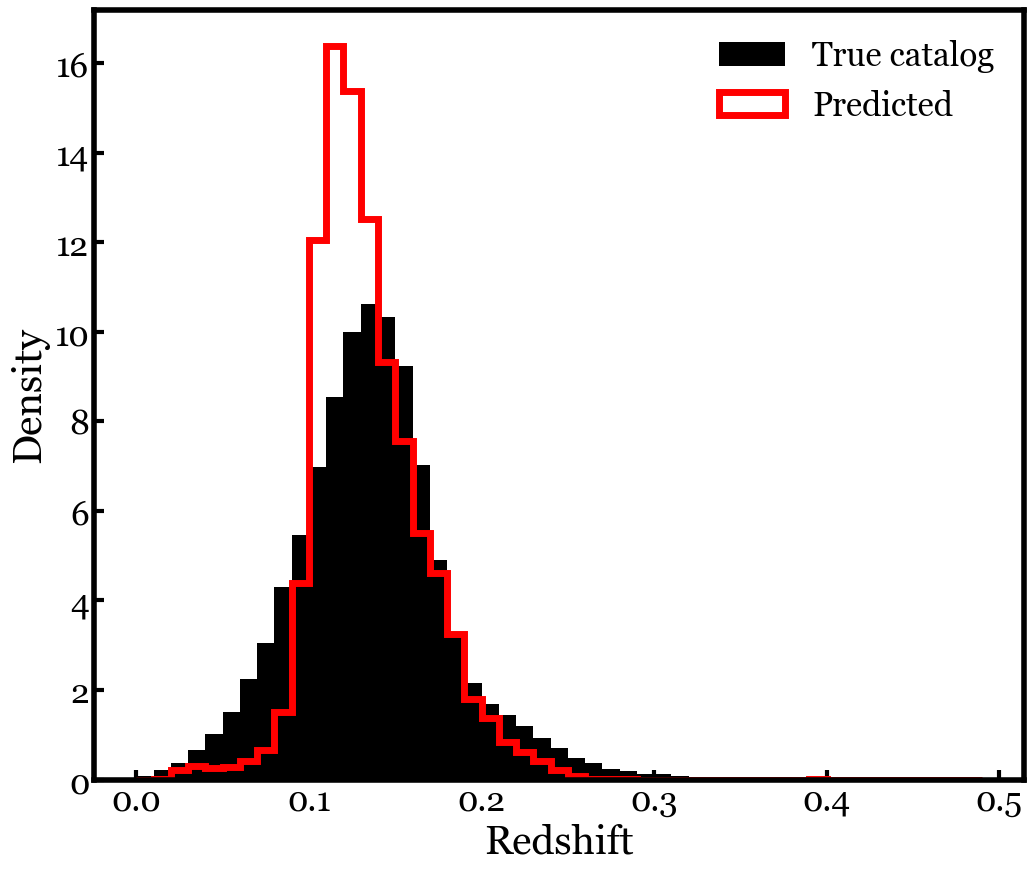

In [12]:
allMedians = flexZBoost_estimator["output"].median()

fig = plt.figure()
ax = fig.add_subplot()

bins = np.arange(0, .5, 0.01)

ax.hist(training_data['redshift'], bins = bins, density = True,
        color = 'black',
        label = 'True catalog')
ax.hist(allMedians, bins = bins, density = True,
        histtype = 'step', color = 'red', linewidth = 5,
        label = 'Predicted')

ax.legend(frameon = False)
ax.set_xlabel('Redshift')
ax.set_ylabel('Density')

In [13]:
x_axis = np.linspace(0, 1, 301)

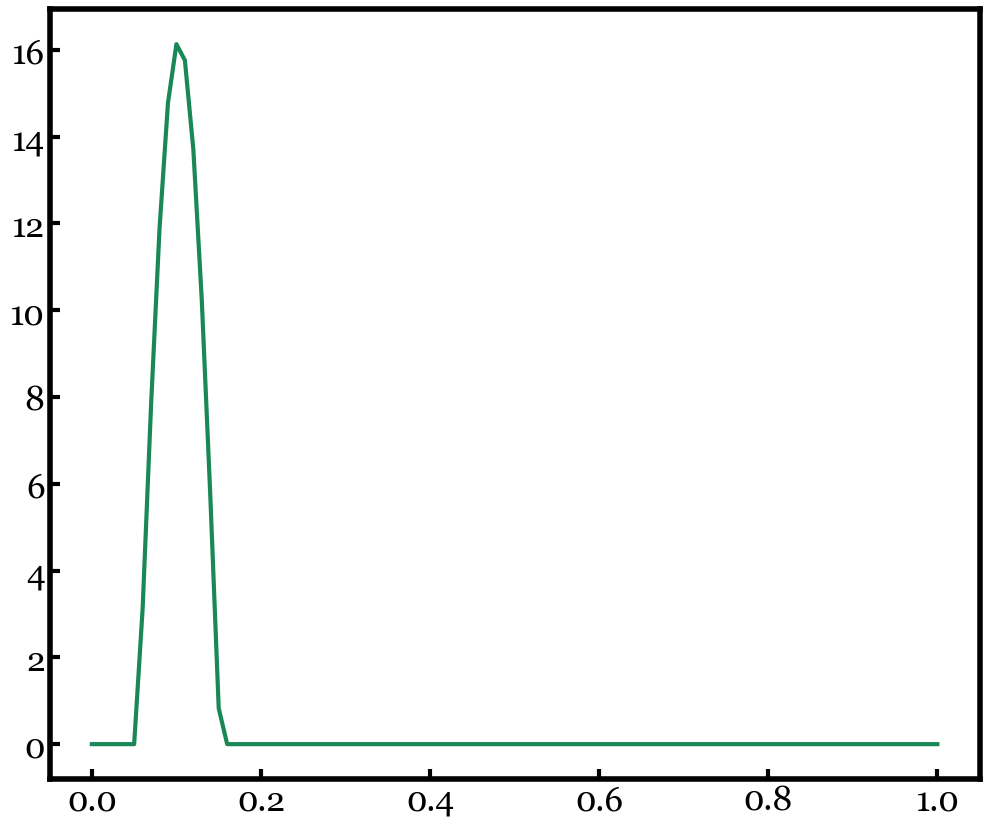

In [14]:
fig = plt.figure()
ax = fig.add_subplot()

sourceID = 39
ax.plot(x_axis, flexZBoost_estimator["output"][sourceID].pdf(x_axis))